# **Predicción de propiedaes mecánicas de aceros con distintas composiciones y trataientos térmicos mediante modelos de aprenizaje automático**

by María Claudia Gamboa Castañeda

Maestría en Ciencia de Datos

## **Carga de librerias y datos**

In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
sns.set(style="whitegrid", palette="viridis")

import matplotlib.pyplot as plt
import math
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Aplicación de filtros**

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/TG. Ciencia de datos MCGC/Desarrollo TG/Data.csv')
data.head()

,Std,ID,Material,Heat treatment,Su,Sy,A5,Bhn,E,G,mu,Ro,pH,Desc,HV
0,ANSI,D8894772B88F495093C43AF905AB6373,Steel SAE 1015,as-rolled,421,314,39.0,126.0,207000,79000,0.3,7860,NaN,NaN,NaN
1,ANSI,05982AC66F064F9EBC709E7A4164613A,Steel SAE 1015,normalized,424,324,37.0,121.0,207000,79000,0.3,7860,NaN,NaN,NaN
2,ANSI,356D6E63FF9A49A3AB23BF66BAC85DC3,Steel SAE 1015,annealed,386,284,37.0,111.0,207000,79000,0.3,7860,NaN,NaN,NaN
3,ANSI,1C758F8714AC4E0D9BD8D8AE1625AECD,Steel SAE 1020,as-rolled,448,331,36.0,143.0,207000,79000,0.3,7860,NaN,NaN,NaN
4,ANSI,DCE10036FC1946FC8C9108D598D116AD,Steel SAE 1020,normalized,441,346,35.8,131.0,207000,79000,0.3,7860,550.0,NaN,NaN


In [ ]:
#material = pd.read_csv('/content/drive/MyDrive/TG. Ciencia de datos MCGC/Desarrollo TG/material.csv')
#material.head()

In [ ]:
steel_data = data[data['Material'].str.contains("Steel", case=False, na=False)]
steel_data.head()

,Std,ID,Material,Heat treatment,Su,Sy,A5,Bhn,E,G,mu,Ro,pH,Desc,HV
0,ANSI,D8894772B88F495093C43AF905AB6373,Steel SAE 1015,as-rolled,421,314,39.0,126.0,207000,79000,0.3,7860,NaN,NaN,NaN
1,ANSI,05982AC66F064F9EBC709E7A4164613A,Steel SAE 1015,normalized,424,324,37.0,121.0,207000,79000,0.3,7860,NaN,NaN,NaN
2,ANSI,356D6E63FF9A49A3AB23BF66BAC85DC3,Steel SAE 1015,annealed,386,284,37.0,111.0,207000,79000,0.3,7860,NaN,NaN,NaN
3,ANSI,1C758F8714AC4E0D9BD8D8AE1625AECD,Steel SAE 1020,as-rolled,448,331,36.0,143.0,207000,79000,0.3,7860,NaN,NaN,NaN
4,ANSI,DCE10036FC1946FC8C9108D598D116AD,Steel SAE 1020,normalized,441,346,35.8,131.0,207000,79000,0.3,7860,550.0,NaN,NaN


In [ ]:
missing_values = steel_data.isnull().sum()
missing_values

,0
Std,0
ID,0
Material,0
Heat treatment,59
Su,0
Sy,0
A5,68
Bhn,176
E,0
G,0


Eliminar filas donde a columna "Heat treatment" tenga valores faltantes

In [ ]:
df = steel_data.dropna(subset=["Heat treatment"])
df.head()

,Std,ID,Material,Heat treatment,Su,Sy,A5,Bhn,E,G,mu,Ro,pH,Desc,HV
0,ANSI,D8894772B88F495093C43AF905AB6373,Steel SAE 1015,as-rolled,421,314,39.0,126.0,207000,79000,0.3,7860,NaN,NaN,NaN
1,ANSI,05982AC66F064F9EBC709E7A4164613A,Steel SAE 1015,normalized,424,324,37.0,121.0,207000,79000,0.3,7860,NaN,NaN,NaN
2,ANSI,356D6E63FF9A49A3AB23BF66BAC85DC3,Steel SAE 1015,annealed,386,284,37.0,111.0,207000,79000,0.3,7860,NaN,NaN,NaN
3,ANSI,1C758F8714AC4E0D9BD8D8AE1625AECD,Steel SAE 1020,as-rolled,448,331,36.0,143.0,207000,79000,0.3,7860,NaN,NaN,NaN
4,ANSI,DCE10036FC1946FC8C9108D598D116AD,Steel SAE 1020,normalized,441,346,35.8,131.0,207000,79000,0.3,7860,550.0,NaN,NaN


Colocar todas las filas de "Heat treatmet" que empiecen en mayusculas

In [ ]:
df["Heat treatment"] = df["Heat treatment"].str.capitalize()

/tmp/ipykernel_1032/1338621274.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Heat treatment"] = df["Heat treatment"].str.capitalize()


In [ ]:
#from google.colab import files

# Guardar el DataFrame en un archivo CSV
#df.to_csv("df.csv", index=False)

# Descargar el archivo al computador
#files.download("df.csv")

## **Análisis exploratorio de datos (EDA)**

Información básica

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395 entries, 0 to 1364
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Std             395 non-null    object 
 1   ID              395 non-null    object 
 2   Material        395 non-null    object 
 3   Heat treatment  395 non-null    object 
 4   Su              395 non-null    int64  
 5   Sy              395 non-null    int64  
 6   A5              327 non-null    float64
 7   Bhn             243 non-null    float64
 8   E               395 non-null    int64  
 9   G               395 non-null    int64  
 10  mu              395 non-null    float64
 11  Ro              395 non-null    int64  
 12  pH              17 non-null     float64
 13  Desc            286 non-null    object 
 14  HV              0 non-null      float64
dtypes: float64(5), int64(5), object(5)
memory usage: 49.4+ KB


Tipos de datos

In [ ]:
df.dtypes

,0
Std,object
ID,object
Material,object
Heat treatment,object
Su,int64
Sy,int64
A5,float64
Bhn,float64
E,int64
G,int64


Tamaño del dataset

In [ ]:
df.shape

(395, 15)

Estadistica descriptiva

In [ ]:
df.describe()

,Su,Sy,A5,Bhn,E,G,mu,Ro,pH,HV
count,395.000000,395.000000,327.000000,243.000000,395.000000,395.000000,395.000000,395.000000,17.000000,0.0
mean,805.972152,557.582278,19.325382,237.358025,205118.987342,166594.936709,0.297139,7865.916456,729.411765,NaN
std,362.635820,368.923458,11.169739,108.278220,5498.824885,226597.818939,0.004525,68.778284,383.723054,NaN
min,290.000000,190.000000,1.000000,111.000000,193000.000000,77000.000000,0.290000,7640.000000,310.000000,NaN
25%,575.000000,320.000000,12.000000,170.000000,200000.000000,79000.000000,0.290000,7820.000000,420.000000,NaN
50%,689.000000,405.000000,17.000000,207.000000,206000.000000,79000.000000,0.300000,7860.000000,550.000000,NaN
75%,916.000000,650.000000,23.000000,255.000000,207000.000000,82000.000000,0.300000,7860.000000,1210.000000,NaN
max,2220.000000,2048.000000,60.000000,627.000000,219000.000000,769000.000000,0.300000,8030.000000,1300.000000,NaN


El dataset cuenta con 1552 registros y 15 columnas que incluyen tanto variables categóricas (ej. Material, Heat treatment) como numéricas (Su, Sy, E, Bhn, HV, etc.).

Existen columnas con valores faltantes significativos: Heat treatment (solo 802 registros completos), Bhn (463), pH (193) y HV (165). Esto indica la necesidad de aplicar técnicas de imputación o descartar variables dependiendo de su relevancia en el modelado.

Consistencia y tipos de datos

Algunas columnas como Sy (límite elástico) están almacenadas como object en lugar de valores numéricos, lo que sugiere que existen caracteres no numéricos o errores de formato. Es necesario realizar limpieza y conversión para aprovechar estas variables en los modelos predictivos.

La resistencia última a la tracción (Su) muestra un rango muy amplio: desde 69 MPa hasta 2220 MPa, lo cual refleja la diversidad de materiales y tratamientos incluidos en la base de datos (desde aceros de baja resistencia hasta aceros de ultra alta resistencia).

La elongación (A5) varía entre 0.5% y 70%, con un promedio de ~19%, lo que indica que el dataset incluye tanto materiales muy frágiles como altamente dúctiles.

La dureza Brinell (Bhn) va de 19 a 627, lo cual confirma la heterogeneidad del conjunto, abarcando desde aceros blandos hasta aleaciones endurecidas por tratamientos térmicos o aleación.

El módulo de elasticidad (E) tiene un rango de 73,000 a 219,000 MPa, con un valor promedio de 165,000 MPa, lo cual es consistente con el rango típico para aceros y metales similares.

El módulo de corte (G) muestra un rango entre 26,000 y 769,000 MPa; el valor máximo parece atípico, lo que sugiere la presencia de outliers o registros con errores que deben ser verificados.

El coeficiente de Poisson (μ) se encuentra en un rango razonable (0.20–0.35), lo que valida la coherencia física de los datos.

Variables adicionales

La columna Ro (densidad) muestra valores entre 1750 y 8930 kg/m³, lo cual refleja la presencia de materiales distintos al acero, posiblemente aleaciones livianas (ej. aluminio o titanio).

La columna pH está incompleta y su utilidad dependerá del enfoque del análisis; no es común en caracterización mecánica de metales.

La columna Desc contiene texto descriptivo y podría usarse como apoyo contextual, pero no como variable numérica directa para los modelos.

Se confirma que el dataset es rico y diverso, adecuado para entrenar modelos de aprendizaje automático, pero requiere un proceso de limpieza y detección de outliers antes de la construcción de modelos.

La gran variabilidad en propiedades como resistencia, dureza y elongación permitirá que los algoritmos identifiquen patrones complejos asociados a la composición química y tratamientos térmicos.

Distribución de variables numéricas

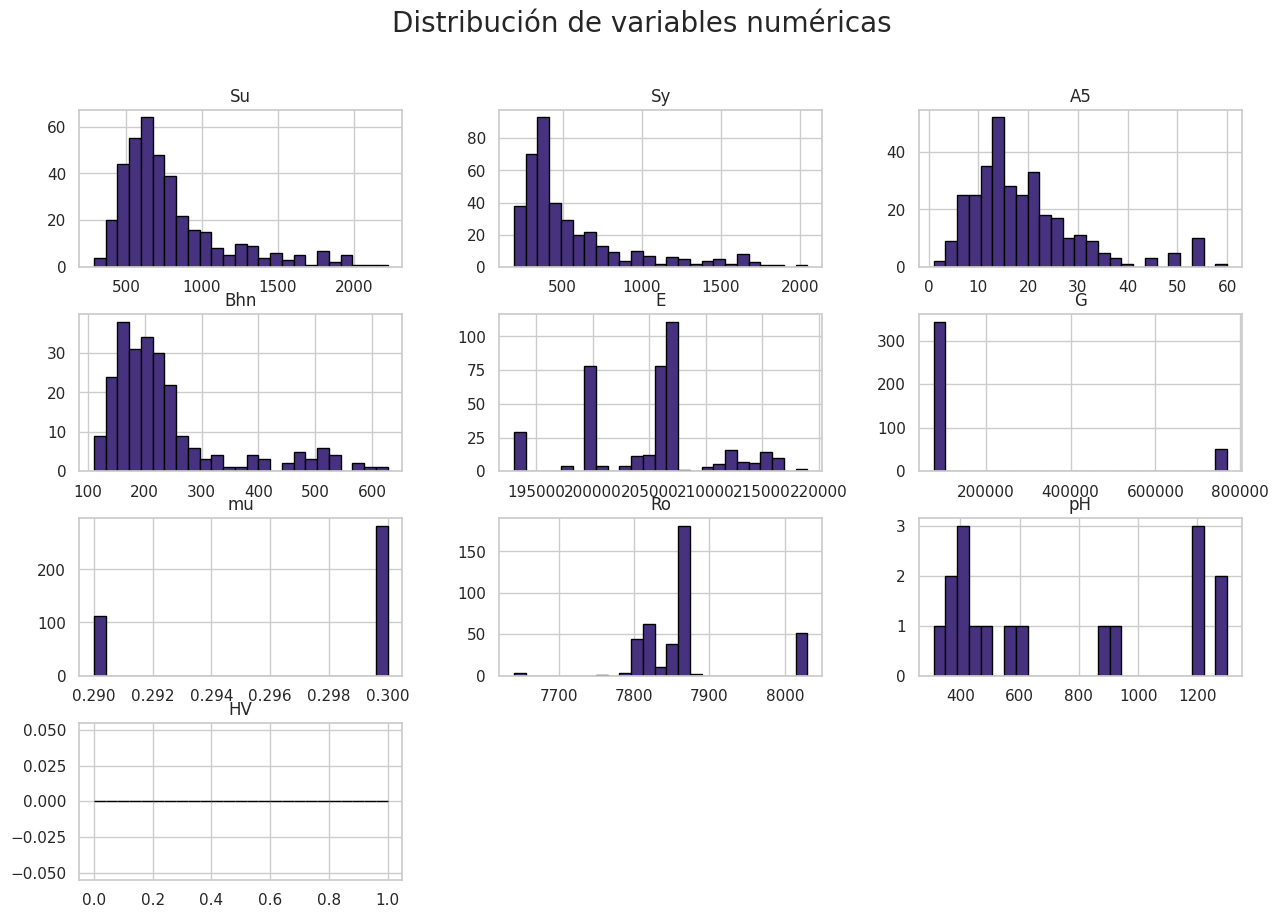

In [ ]:
df.hist(bins=25, figsize=(15,10), edgecolor='black')
plt.suptitle("Distribución de variables numéricas", fontsize=20)
plt.show()

En general, las distribuciones muestran comportamientos heterogéneos entre las variables, lo que evidencia la diversidad de aceros incluidos y la presencia de múltiples composiciones químicas y tratamientos térmicos. Algunas variables tienen una dispersión amplia y otras exhiben valores altamente concentrados.

Variables como Su (resistencia última), A5 (elongación) y Bhn (dureza Brinell) muestran distribuciones con una mayor densidad en rangos intermedios y presencia de valores altos menos frecuentes. Este sesgo positivo = la mayoria de los aceros presentan propiedades mecánicas moderadas
Valores extremos = aleaciones altamente aleadas o sometidas a tratamientos térmicos específicos que aumentan su resistencia o dureza.

Variables como E (módulo de elasticidad) y G (módulo de corte) presentan distribuciones notablemente discretizadas en “bloques”, lo cual indica que los valores reportados provienen probablemente de fuentes experimentales estandarizadas o de mediciones típicas para determinados grupos de aceros.

La variable mu (coeficiente de Poisson) muestra una distribución extremadamente concentrada, prácticamente sin variación. Esto implica que esta característica podría tener una contribución no esencial.

Boxplot para detección de outliers

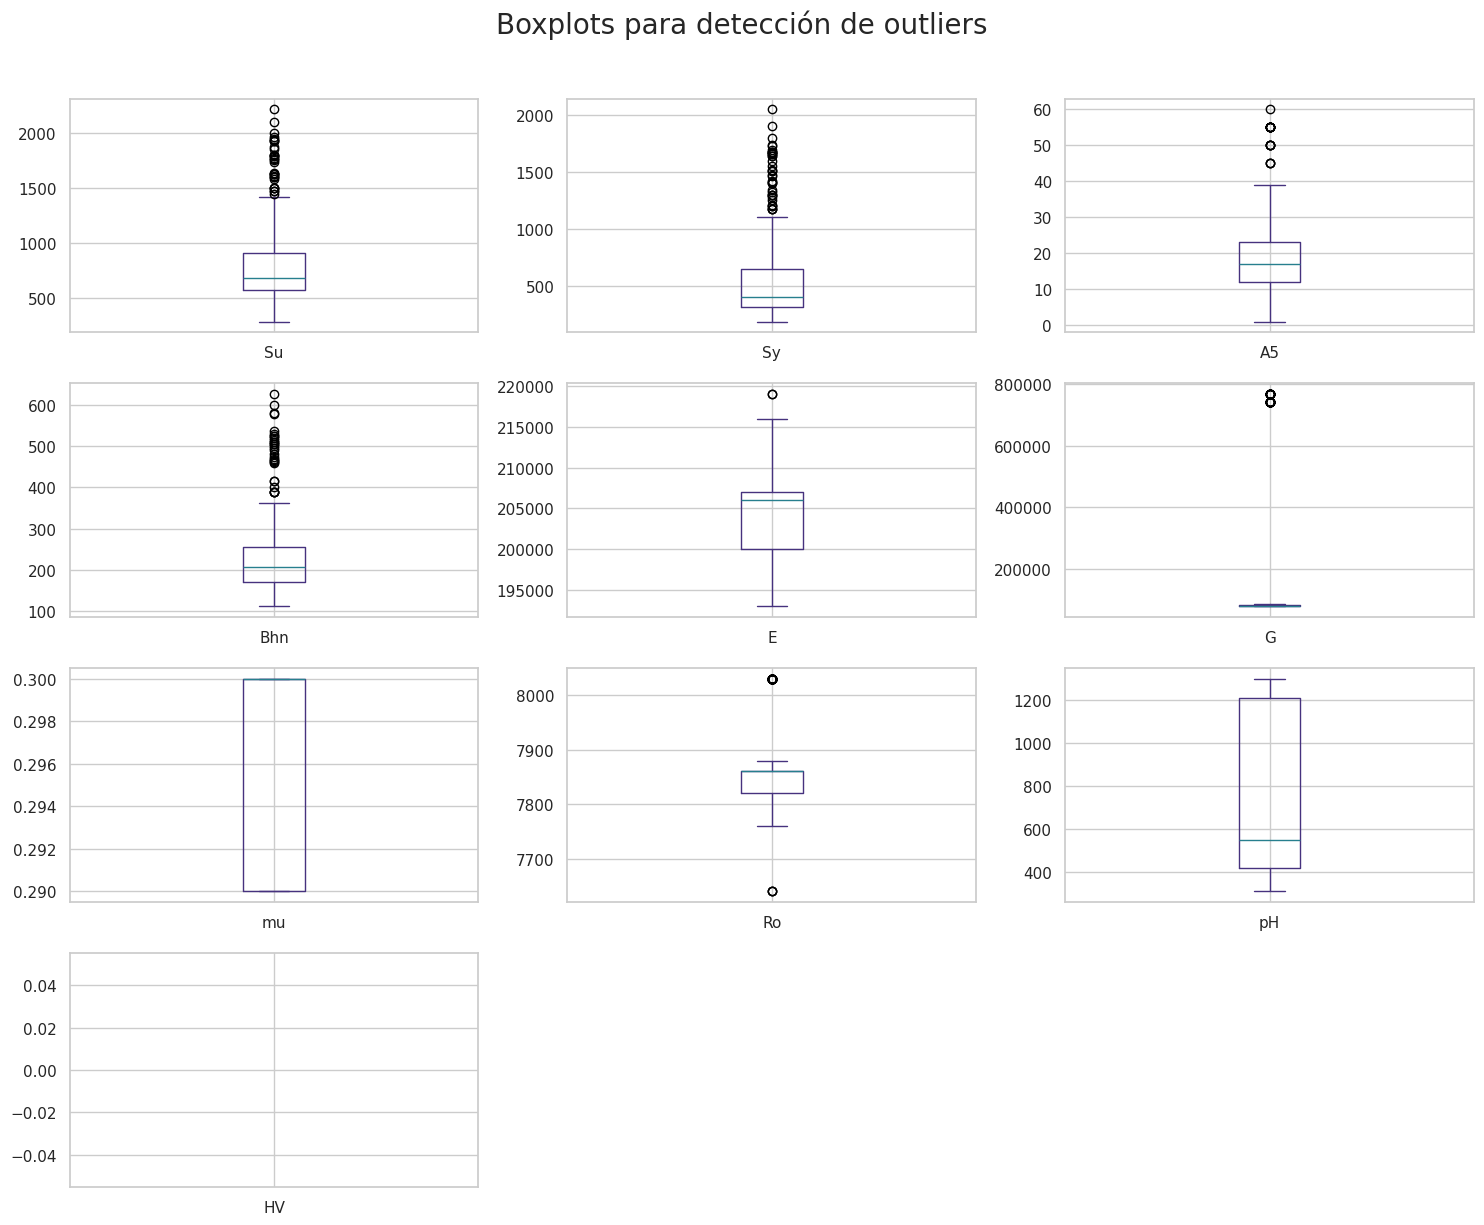

In [ ]:
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
cols = 3
n = len(numeric_cols)
rows = int(np.ceil(n / cols))

df[numeric_cols].plot(
    kind='box',
    subplots=True, layout=(rows, cols), figsize=(15, rows * 3),
    sharex=False, sharey=False)

plt.suptitle("Boxplots para detección de outliers", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

Matriz de correlación

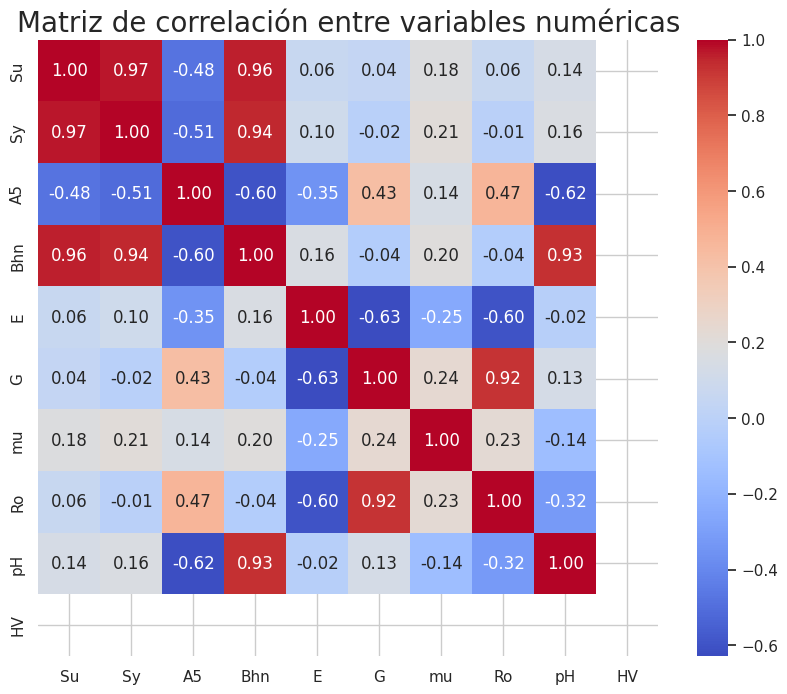

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas", fontsize=20)
plt.show()

Puede ser pesado, se recomienda seleccionar algunas columnas

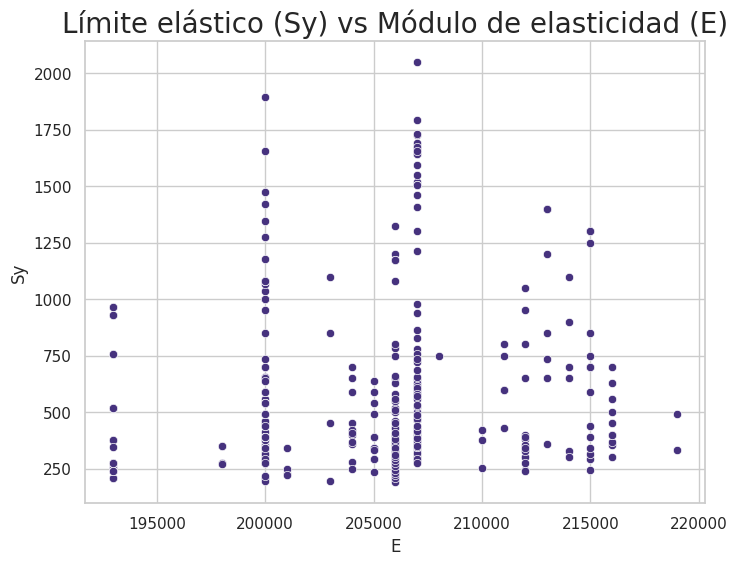

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='E', y='Sy', data=df)
plt.title("Límite elástico (Sy) vs Módulo de elasticidad (E)", fontsize=20)
plt.show()

Distribución por tratamiento térmico

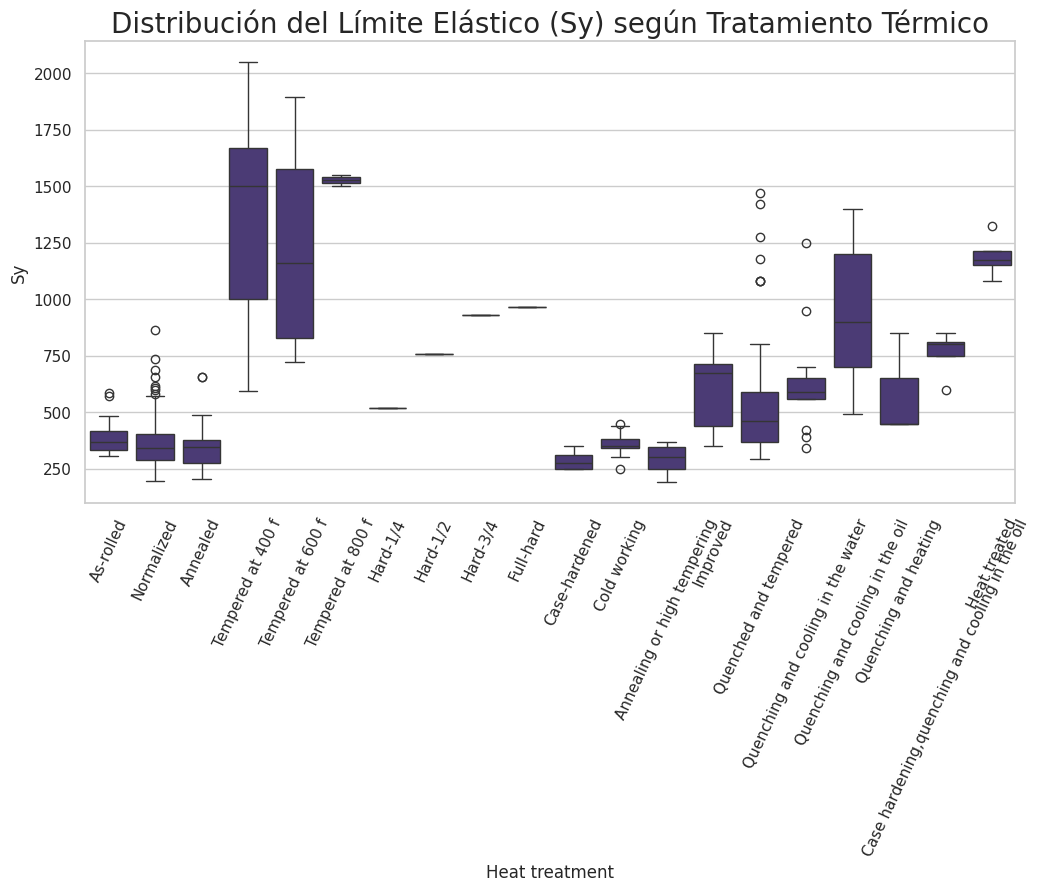

In [ ]:
if 'Heat treatment' in df.columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(x='Heat treatment', y='Sy', data=df)
    plt.title("Distribución del Límite Elástico (Sy) según Tratamiento Térmico", fontsize=20)
    plt.xticks(rotation=65)
    plt.show()

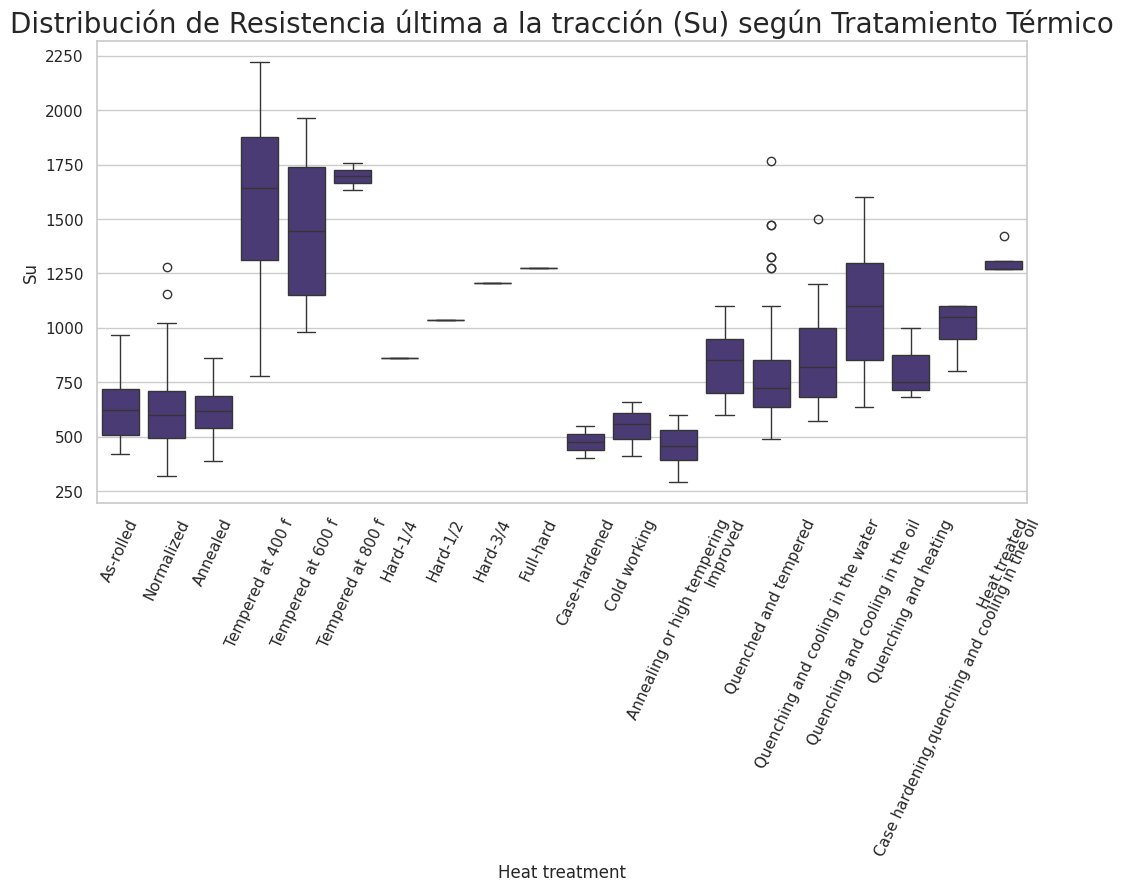

In [ ]:
if 'Heat treatment' in df.columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(x='Heat treatment', y='Su', data=df)
    plt.title("Distribución de Resistencia última a la tracción (Su) según Tratamiento Térmico", fontsize=20)
    plt.xticks(rotation=65)
    plt.show()

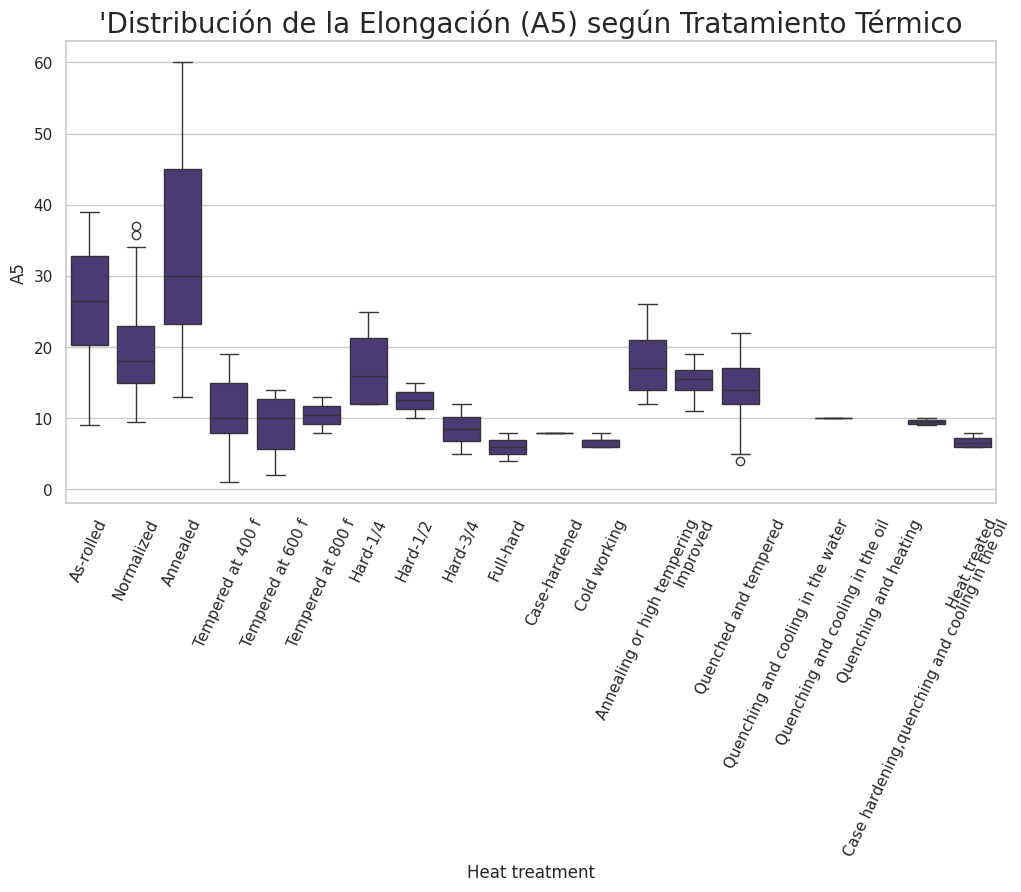

In [ ]:
if 'Heat treatment' in df.columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(x='Heat treatment', y='A5', data=df)
    plt.title("'Distribución de la Elongación (A5) según Tratamiento Térmico", fontsize=20)
    plt.xticks(rotation=65)
    plt.show()

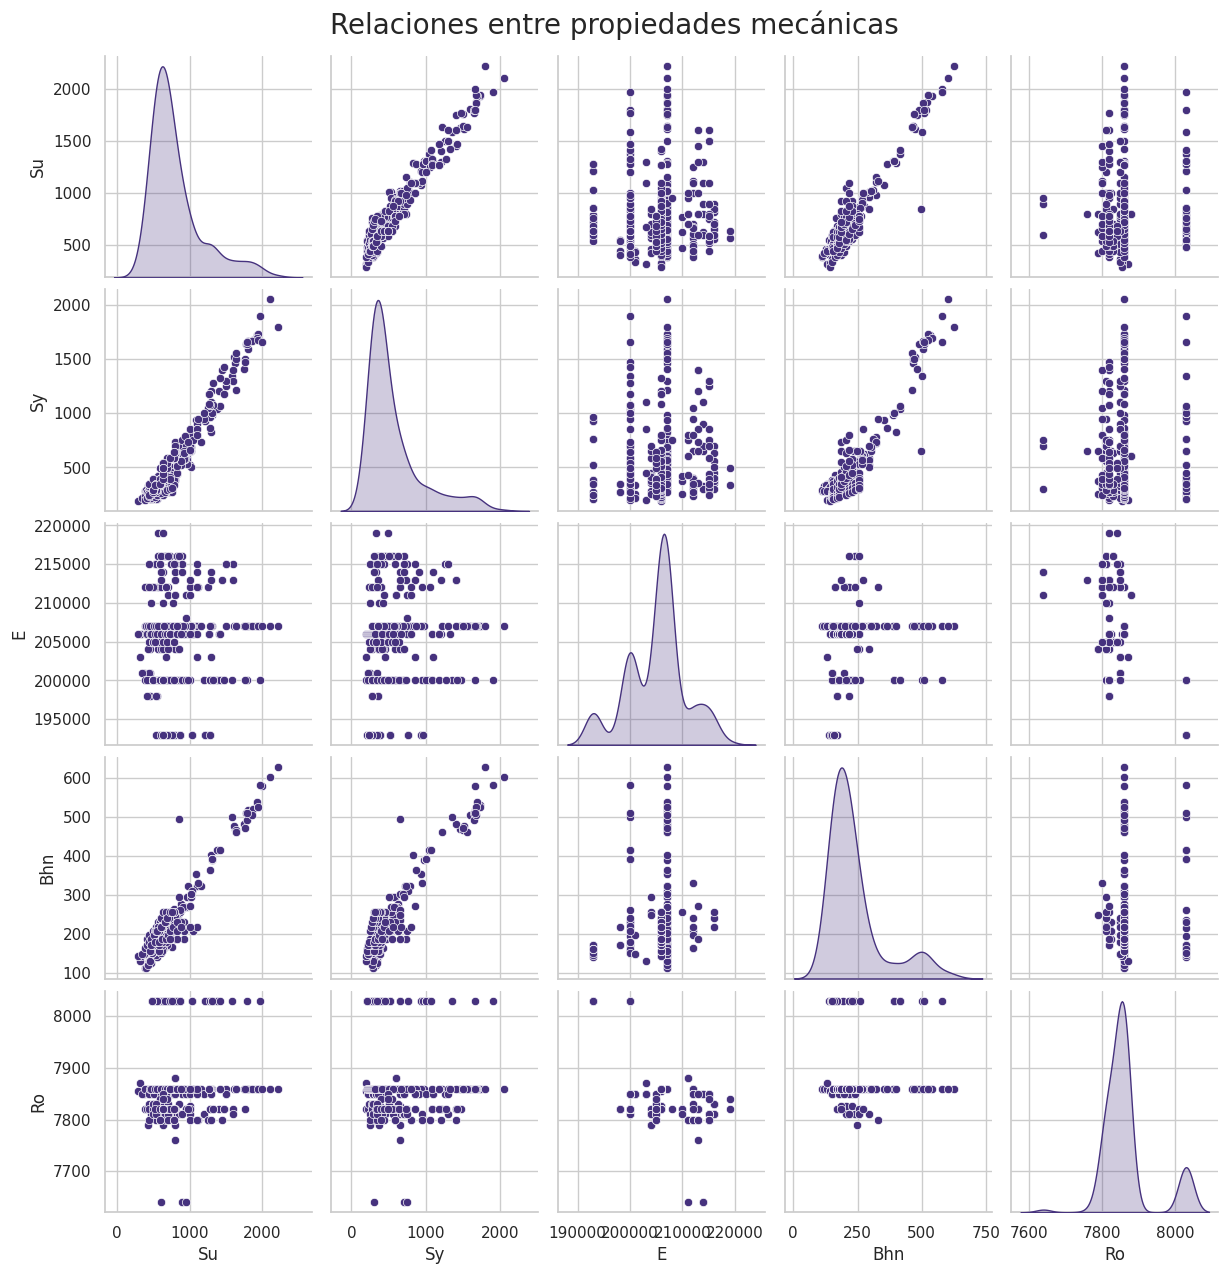

In [ ]:
sns.pairplot(df[['Su','Sy','E','Bhn','Ro']], diag_kind='kde')
plt.suptitle("Relaciones entre propiedades mecánicas", fontsize=20, y=1.02)
plt.show()

Conteo de tratamientos termicos

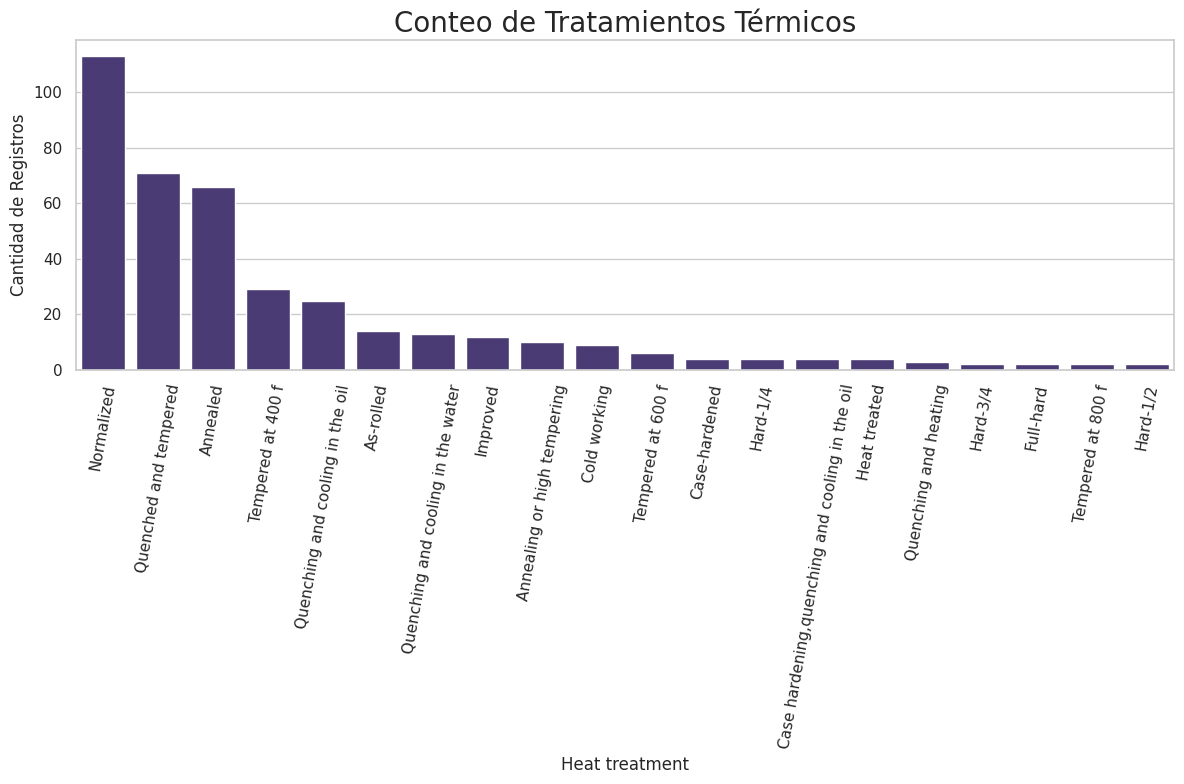

In [ ]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x='Heat treatment',order=df['Heat treatment'].value_counts().index)

plt.title('Conteo de Tratamientos Térmicos', fontsize=20)
plt.xlabel('Heat treatment')
plt.ylabel('Cantidad de Registros')
plt.xticks(rotation=80)

plt.tight_layout()
plt.show()

## **Datos sinteticos de la composición química**

Definir rangos por aleación

In [ ]:
rangos = {
   "Steel 25ChS GOST 4543-71": {
        "C": (0.62, 0.70),
        "Mn": (0.9, 1.20),
        "P": (0.0, 0.035),
        "S": (0.00, 0.35),
        "Si": (0.17, 0.37),
        "Ni": (0.0, 0.0),
        "Cr": (0.00, 0.00),
        "Mo": (0.00, 0.00)
        },
}

In [ ]:
def generar_composicion(rangos_aleacion, n=100):
    registros = []
    for _ in range(n):
        fila = {}
        subtotal = 0

        # Generar valores dentro del rango
        for elemento, (mn, mx) in rangos_aleacion.items():
            valor = np.random.uniform(mn, mx)
            fila[elemento] = valor
            subtotal += valor

        # Ajustar Fe para llegar al 100%
        Fe = 100 - subtotal
        if Fe < 0:
            Fe = max(0, Fe)  # Evitar negativos

        fila["Fe"] = Fe
        registros.append(fila)

    return pd.DataFrame(registros)

In [ ]:
df_final = []

for aleacion, r in rangos.items():
    df_temp = generar_composicion(r, n=5)  # número de registros por aleación
    df_temp["Aleacion"] = aleacion
    df_final.append(df_temp)

df_final = pd.concat(df_final, ignore_index=True)

In [ ]:
df_final.to_csv("composiciones_sinteticas.csv", index=False)
df_final

,C,Mn,P,S,Si,Ni,Cr,Mo,Fe,Aleacion
0,0.691354,1.130094,0.006071,0.214941,0.297265,0.0,0.0,0.0,97.660275,Steel 25ChS GOST 4543-71
1,0.670711,0.978332,0.004846,0.335692,0.179067,0.0,0.0,0.0,97.831353,Steel 25ChS GOST 4543-71
2,0.687556,0.960815,0.023936,0.124256,0.210197,0.0,0.0,0.0,97.993240,Steel 25ChS GOST 4543-71
3,0.666458,0.939472,0.003201,0.248111,0.188021,0.0,0.0,0.0,97.954736,Steel 25ChS GOST 4543-71
4,0.678331,0.983884,0.028231,0.049703,0.356096,0.0,0.0,0.0,97.903754,Steel 25ChS GOST 4543-71


## **Preparación de los datos**

Quitar los otliers de la columna "G", ya que solo en esta se encuentran los valores atípicos más grandes

In [ ]:
df = df[df['G'] <= 100000]
df = df.reset_index(drop=True)

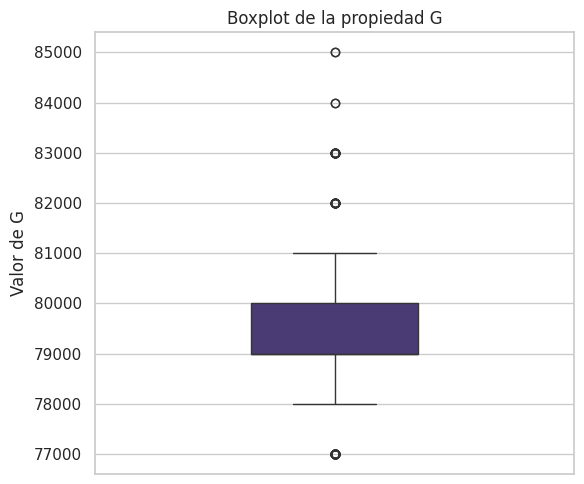

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df['G'], width=0.35)
plt.title('Boxplot de la propiedad G')
plt.ylabel('Valor de G')
plt.tight_layout()
plt.show()

Eliminar las columnas "pH", "Desc" y "HV" ya que están practicamente desocupadas

In [ ]:
df = df.drop(columns=['pH', 'Desc', 'HV'], errors='ignore')
df.head()

,Std,ID,Material,Heat treatment,Su,Sy,A5,Bhn,E,G,mu,Ro
0,ANSI,D8894772B88F495093C43AF905AB6373,Steel SAE 1015,As-rolled,421,314,39.0,126.0,207000,79000,0.3,7860
1,ANSI,05982AC66F064F9EBC709E7A4164613A,Steel SAE 1015,Normalized,424,324,37.0,121.0,207000,79000,0.3,7860
2,ANSI,356D6E63FF9A49A3AB23BF66BAC85DC3,Steel SAE 1015,Annealed,386,284,37.0,111.0,207000,79000,0.3,7860
3,ANSI,1C758F8714AC4E0D9BD8D8AE1625AECD,Steel SAE 1020,As-rolled,448,331,36.0,143.0,207000,79000,0.3,7860
4,ANSI,DCE10036FC1946FC8C9108D598D116AD,Steel SAE 1020,Normalized,441,346,35.8,131.0,207000,79000,0.3,7860


In [ ]:
#from google.colab import files

# Guardar el DataFrame en un archivo CSV
#df_clean.to_csv("df_clean.csv", index=False)

# Descargar el archivo al computador
#files.download("df_clean.csv")

Verificar que tienen el mismo número de filas

In [ ]:
df.shape

(344, 12)

In [ ]:
df_cq = pd.read_csv('/content/drive/MyDrive/TG. Ciencia de datos MCGC/Desarrollo TG/composicion_quimica.csv')
df_cq.head()

,Material,C,Mn,P,S,Si,Ni,Cr,Mo,Fe
0,Steel SAE 1015,0.136184,0.342828,0.001075,0.007927,0.0,0.0,0.0,0.0,99.511986
1,Steel SAE 1015,0.149983,0.563571,0.027726,0.028617,0.0,0.0,0.0,0.0,99.230103
2,Steel SAE 1015,0.172061,0.356569,0.002655,0.045889,0.0,0.0,0.0,0.0,99.422826
3,Steel SAE 1020,0.220168,0.455266,0.027873,0.020515,0.0,0.0,0.0,0.0,99.276178
4,Steel SAE 1020,0.222798,0.465205,0.014807,0.036727,0.0,0.0,0.0,0.0,99.260463


In [ ]:
df_cq.shape

(344, 10)

###  Imputación de datos

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
#Variables predictoras
features = ['Su', 'Sy', 'E', 'G', 'mu', 'Ro']

Imputación de datos en la columna A5

In [ ]:
# Filas con A5 conocido
df_A5_train = df[df['A5'].notna()]
# Filas con A5 faltante
df_A5_missing = df[df['A5'].isna()]

In [ ]:
# Entrenamiento
rf_A5 = RandomForestRegressor(n_estimators=300, random_state=42)
rf_A5.fit(df_A5_train[features], df_A5_train['A5'])

RandomForestRegressor(n_estimators=300, random_state=42)

In [ ]:
# Predicción
pred_A5 = rf_A5.predict(df_A5_missing[features])

In [ ]:
# Insertar imputación
df.loc[df['A5'].isna(), 'A5'] = pred_A5

Imputación de datos en la columna Bhn

In [ ]:
# Filas con Bhn conocido
df_Bhn_train = df[df['Bhn'].notna()]
# Filas con Bhn faltante
df_Bhn_missing = df[df['Bhn'].isna()]

In [ ]:
# Entrenamiento
rf_Bhn = RandomForestRegressor(n_estimators=300, random_state=42)
rf_Bhn.fit(df_Bhn_train[features], df_Bhn_train['Bhn'])

RandomForestRegressor(n_estimators=300, random_state=42)

In [ ]:
# Predicción
pred_Bhn = rf_Bhn.predict(df_Bhn_missing[features])

In [ ]:
# Insertar imputación
df.loc[df['Bhn'].isna(), 'Bhn'] = pred_Bhn

Dataframe limpio e imputado

In [ ]:
df_imputed = df.copy()

In [ ]:
df = df_imputed
df.head()

,Std,ID,Material,Heat treatment,Su,Sy,A5,Bhn,E,G,mu,Ro
0,ANSI,D8894772B88F495093C43AF905AB6373,Steel SAE 1015,As-rolled,421,314,39.0,126.0,207000,79000,0.3,7860
1,ANSI,05982AC66F064F9EBC709E7A4164613A,Steel SAE 1015,Normalized,424,324,37.0,121.0,207000,79000,0.3,7860
2,ANSI,356D6E63FF9A49A3AB23BF66BAC85DC3,Steel SAE 1015,Annealed,386,284,37.0,111.0,207000,79000,0.3,7860
3,ANSI,1C758F8714AC4E0D9BD8D8AE1625AECD,Steel SAE 1020,As-rolled,448,331,36.0,143.0,207000,79000,0.3,7860
4,ANSI,DCE10036FC1946FC8C9108D598D116AD,Steel SAE 1020,Normalized,441,346,35.8,131.0,207000,79000,0.3,7860


In [ ]:
#from google.colab import files

# Guardar el DataFrame en un archivo CSV
#df_imputed.to_csv("df_imputed.csv", index=False)

# Descargar el archivo al computador
#files.download("df_imputed.csv")

Cambio de unidades de E y G

In [ ]:
#df["E"] = df["E"] / 1000
#df["G"] = df["G"] / 1000

In [ ]:
#df.head()

### Union de los dos dataframes

In [ ]:
df_total = pd.concat([df, df_cq], axis=1)
df_total.head(3)

,Std,ID,Material,Heat treatment,Su,Sy,A5,Bhn,E,G,...,Material,C,Mn,P,S,Si,Ni,Cr,Mo,Fe
0,ANSI,D8894772B88F495093C43AF905AB6373,Steel SAE 1015,As-rolled,421,314,39.0,126.0,207000,79000,...,Steel SAE 1015,0.136184,0.342828,0.001075,0.007927,0.0,0.0,0.0,0.0,99.511986
1,ANSI,05982AC66F064F9EBC709E7A4164613A,Steel SAE 1015,Normalized,424,324,37.0,121.0,207000,79000,...,Steel SAE 1015,0.149983,0.563571,0.027726,0.028617,0.0,0.0,0.0,0.0,99.230103
2,ANSI,356D6E63FF9A49A3AB23BF66BAC85DC3,Steel SAE 1015,Annealed,386,284,37.0,111.0,207000,79000,...,Steel SAE 1015,0.172061,0.356569,0.002655,0.045889,0.0,0.0,0.0,0.0,99.422826


In [ ]:
df_mix = df_total.loc[:, ~df_total.columns.duplicated()]
df_mix = df_mix.drop(columns=['Std', 'ID'], errors='ignore')
df_mix.head()

,Material,Heat treatment,Su,Sy,A5,Bhn,E,G,mu,Ro,C,Mn,P,S,Si,Ni,Cr,Mo,Fe
0,Steel SAE 1015,As-rolled,421,314,39.0,126.0,207000,79000,0.3,7860,0.136184,0.342828,0.001075,0.007927,0.0,0.0,0.0,0.0,99.511986
1,Steel SAE 1015,Normalized,424,324,37.0,121.0,207000,79000,0.3,7860,0.149983,0.563571,0.027726,0.028617,0.0,0.0,0.0,0.0,99.230103
2,Steel SAE 1015,Annealed,386,284,37.0,111.0,207000,79000,0.3,7860,0.172061,0.356569,0.002655,0.045889,0.0,0.0,0.0,0.0,99.422826
3,Steel SAE 1020,As-rolled,448,331,36.0,143.0,207000,79000,0.3,7860,0.220168,0.455266,0.027873,0.020515,0.0,0.0,0.0,0.0,99.276178
4,Steel SAE 1020,Normalized,441,346,35.8,131.0,207000,79000,0.3,7860,0.222798,0.465205,0.014807,0.036727,0.0,0.0,0.0,0.0,99.260463


In [ ]:
#from google.colab import files

# Guardar el DataFrame en un archivo CSV
#df_mix.to_csv("df_mix.csv", index=False)

# Descargar el archivo al computador
#files.download("df_mix.csv")

###  Codificación de variables categóricas

In [ ]:
df = pd.get_dummies(df_mix, columns=["Heat treatment"], prefix="HT")
df.head()

,Material,Su,Sy,A5,Bhn,E,G,mu,Ro,C,...,HT_Heat treated,HT_Improved,HT_Normalized,HT_Quenched and tempered,HT_Quenching and cooling in the oil,HT_Quenching and cooling in the water,HT_Quenching and heating,HT_Tempered at 400 f,HT_Tempered at 600 f,HT_Tempered at 800 f
0,Steel SAE 1015,421,314,39.0,126.0,207000,79000,0.3,7860,0.136184,...,False,False,False,False,False,False,False,False,False,False
1,Steel SAE 1015,424,324,37.0,121.0,207000,79000,0.3,7860,0.149983,...,False,False,True,False,False,False,False,False,False,False
2,Steel SAE 1015,386,284,37.0,111.0,207000,79000,0.3,7860,0.172061,...,False,False,False,False,False,False,False,False,False,False
3,Steel SAE 1020,448,331,36.0,143.0,207000,79000,0.3,7860,0.220168,...,False,False,False,False,False,False,False,False,False,False
4,Steel SAE 1020,441,346,35.8,131.0,207000,79000,0.3,7860,0.222798,...,False,False,True,False,False,False,False,False,False,False


In [ ]:
df.columns

Index(['Material', 'Su', 'Sy', 'A5', 'Bhn', 'E', 'G', 'mu', 'Ro', 'C', 'Mn',
       'P', 'S', 'Si', 'Ni', 'Cr', 'Mo', 'Fe', 'HT_Annealed',
       'HT_Annealing or high tempering', 'HT_As-rolled',
       'HT_Case hardening,quenching and cooling in the oil',
       'HT_Case-hardened', 'HT_Cold working', 'HT_Heat treated', 'HT_Improved',
       'HT_Normalized', 'HT_Quenched and tempered',
       'HT_Quenching and cooling in the oil',
       'HT_Quenching and cooling in the water', 'HT_Quenching and heating',
       'HT_Tempered at 400 f', 'HT_Tempered at 600 f', 'HT_Tempered at 800 f'],
      dtype='object')

In [ ]:
#from google.colab import files

# Guardar el DataFrame en un archivo CSV
#df_encoded.to_csv("df_encoded.csv", index=False)

# Descargar el archivo al computador
#files.download("df_encoded.csv")

## **Desarrollo de modelos**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

#### Variables de entrada

In [ ]:
heat_treat_cols = [col for col in df.columns if col.startswith("HT_")]

X = df[['C','Mn', 'P', 'S', 'Si', 'Ni', 'Cr', 'Mo', 'Fe', 'Bhn', 'Ro']+heat_treat_cols]

###  **Random forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

#### Modelo Su - Resistencia a la últma tracción

In [ ]:
y_rfsu = df['Su']

In [ ]:
X_train_rfsu, X_test_rfsu, y_train_rfsu, y_test_rfsu = train_test_split(X, y_rfsu, test_size=0.2, random_state=42) #Resistencia última a la tracción

In [ ]:
rfsu = RandomForestRegressor(n_estimators=300, random_state=42)
rfsu.fit(X_train_rfsu, y_train_rfsu)

RandomForestRegressor(n_estimators=300, random_state=42)

In [ ]:
y_pred_rfsu = rfsu.predict(X_test_rfsu)

In [ ]:
R2_rfsu = r2_score(y_test_rfsu, y_pred_rfsu)
R2_rfsu

0.9397781023650595

In [ ]:
MAPE_rfsu = np.mean(np.abs((y_test_rfsu - y_pred_rfsu) / y_test_rfsu)) * 100
MAPE_rfsu

np.float64(9.194663936220032)

In [ ]:
MAE_rfsu = mean_absolute_error(y_test_rfsu, y_pred_rfsu)
MAE_rfsu

63.45367149758454

In [ ]:
MSE_rfsu = mean_squared_error(y_test_rfsu, y_pred_rfsu)

RMSE_rfsu = np.sqrt(MSE_rfsu)
RMSE_rfsu

np.float64(89.06516971228211)

In [ ]:
df_results_rfsu = pd.DataFrame({'Su_real': y_test_rfsu.values, 'Su_predicho': y_pred_rfsu})
df_results_rfsu.head()

,Su_real,Su_predicho
0,950,813.526667
1,630,737.936667
2,495,495.866667
3,1200,1134.666667
4,638,711.683333


In [ ]:
df_results_rfsu = np.abs((df_results_rfsu["Su_real"] - df_results_rfsu["Su_predicho"]) / df_results_rfsu["Su_real"]) * 100

error_promedio_rfsu = df_results_rfsu.mean()
error_promedio_rfsu

np.float64(9.194663936220032)

#### Modelo Sy - Límite elástico

In [ ]:
y_rfsy = df['Sy']

In [ ]:
X_train_rfsy, X_test_rfsy, y_train_rfsy, y_test_rfsy = train_test_split(X, y_rfsy, test_size=0.2, random_state=42)

In [ ]:
rfsy = RandomForestRegressor(n_estimators=300, random_state=42)
rfsy.fit(X_train_rfsy, y_train_rfsy)

RandomForestRegressor(n_estimators=300, random_state=42)

In [ ]:
y_pred_rfsy = rfsy.predict(X_test_rfsy)

In [ ]:
R2_rfsy = r2_score(y_test_rfsy, y_pred_rfsy)
R2_rfsy

0.9453549240019448

In [ ]:
MAPE_rfsy = np.mean(np.abs((y_test_rfsy - y_pred_rfsy) / y_test_rfsy)) * 100
MAPE_rfsy

np.float64(12.871493750615121)

In [ ]:
MAE_rfsy = mean_absolute_error(y_test_rfsy, y_pred_rfsy)
MAE_rfsy

61.23966183574877

In [ ]:
MSE_rfsy = mean_squared_error(y_test_rfsy, y_pred_rfsy)

RMSE_rfsy = np.sqrt(MSE_rfsy)
RMSE_rfsy

np.float64(85.21219563645327)

In [ ]:
df_results_rfsy = pd.DataFrame({'Sy_real': y_test_rfsy.values, 'Sy_predicho': y_pred_rfsy})
df_results_rfsy.head()

,Sy_real,Sy_predicho
0,750,647.776667
1,375,472.866667
2,260,267.556667
3,1000,850.486667
4,392,614.013333


In [ ]:
df_results_rfsy = np.abs((df_results_rfsy["Sy_real"] - df_results_rfsy["Sy_predicho"]) / df_results_rfsy["Sy_real"]) * 100

error_promedio_rfsy = df_results_rfsy.mean()
error_promedio_rfsy

np.float64(12.871493750615121)

#### Modelo A5 - Elongación

In [ ]:
y_rfa = df['A5']

In [ ]:
X_train_rfa, X_test_rfa, y_train_rfa, y_test_rfa = train_test_split(X, y_rfa, test_size=0.2, random_state=42)

In [ ]:
rfa = RandomForestRegressor(n_estimators=300, random_state=42)
rfa.fit(X_train_rfa, y_train_rfa)

RandomForestRegressor(n_estimators=300, random_state=42)

In [ ]:
y_pred_rfa = rfa.predict(X_test_rfa)

In [ ]:
R2_rfa = r2_score(y_test_rfa, y_pred_rfa)
R2_rfa

0.8590662468911292

In [ ]:
MAPE_rfa = np.mean(np.abs((y_test_rfa - y_pred_rfa) / y_test_rfa)) * 100
MAPE_rfa

np.float64(17.18350584073514)

In [ ]:
MAE_rfa = mean_absolute_error(y_test_rfa, y_pred_rfa)
MAE_rfa

2.2868277148991685

In [ ]:
MSE_rfa = mean_squared_error(y_test_rfa, y_pred_rfa)

RMSE_rfa = np.sqrt(MSE_rfa)
RMSE_rfa

np.float64(3.0148231749285936)

In [ ]:
df_results_rfa = pd.DataFrame({'A5_real': y_test_rfa.values, 'A5_predicho': y_pred_rfa})
df_results_rfa.head()

,A5_real,A5_predicho
0,10.357000,13.600611
1,13.000000,14.388795
2,25.000000,23.664000
3,7.041849,9.869097
4,14.000000,12.860371


In [ ]:
df_results_rfa = np.abs((df_results_rfa["A5_real"] - df_results_rfa["A5_predicho"]) / df_results_rfa["A5_real"]) * 100

error_promedio_rfa = df_results_rfa.mean()
error_promedio_rfa

np.float64(17.183505840735144)

#### Modelo E - módulo de elasticidad

In [ ]:
y_rfe = df['E']

In [ ]:
X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(X, y_rfe, test_size=0.2, random_state=42)

In [ ]:
rfe = RandomForestRegressor(n_estimators=300, random_state=42)
rfe.fit(X_train_rfe, y_train_rfe)

RandomForestRegressor(n_estimators=300, random_state=42)

In [ ]:
y_pred_rfe = rfe.predict(X_test_rfe)

In [ ]:
R2_rfe = r2_score(y_test_rfe, y_pred_rfe)
R2_rfe

0.3036226539380521

In [ ]:
MAPE_rfe = np.mean(np.abs((y_test_rfe - y_pred_rfe) / y_test_rfe)) * 100
MAPE_rfe

np.float64(1.0371861006585281)

In [ ]:
MAE_rfe = mean_absolute_error(y_test_rfe, y_pred_rfe)
MAE_rfe

2162.6570048309186

In [ ]:
MSE_rfe = mean_squared_error(y_test_rfe, y_pred_rfe)

RMSE_rfe = np.sqrt(MSE_rfe)
RMSE_rfe

np.float64(3653.096165474281)

In [ ]:
df_results_rfe = pd.DataFrame({'E_real': y_test_rfe.values, 'E_predicho': y_pred_rfe})
df_results_rfe.head()

,E_real,E_predicho
0,208000,210403.333333
1,210000,208136.666667
2,206000,206043.333333
3,200000,213203.333333
4,200000,201123.333333


In [ ]:
df_results_rfe = np.abs((df_results_rfe["E_real"] - df_results_rfe["E_predicho"]) / df_results_rfe["E_real"]) * 100

error_promedio_rfe = df_results_rfe.mean()
error_promedio_rfe

np.float64(1.037186100658528)

#### Modelo G - Módulo de corte

In [ ]:
y_rfg = df['G']

In [ ]:
X_train_rfg, X_test_rfg, y_train_rfg, y_test_rfg = train_test_split(X, y_rfg, test_size=0.2, random_state=42)

In [ ]:
rfg = RandomForestRegressor(n_estimators=300, random_state=42)
rfg.fit(X_train_rfg, y_train_rfg)

RandomForestRegressor(n_estimators=300, random_state=42)

In [ ]:
y_pred_rfg = rfg.predict(X_test_rfg)

In [ ]:
R2_rfg = r2_score(y_test_rfg, y_pred_rfg)
R2_rfg

0.26560655430711655

In [ ]:
MAPE_rfg = np.mean(np.abs((y_test_rfg - y_pred_rfg) / y_test_rfg)) * 100
MAPE_rfg

np.float64(1.211246300509785)

In [ ]:
MAE_rfg = mean_absolute_error(y_test_rfg, y_pred_rfg)
MAE_rfg

974.4444444444439

In [ ]:
MSE_rfg = mean_squared_error(y_test_rfg, y_pred_rfg)

RMSE_rfg = np.sqrt(MSE_rfg)
RMSE_rfg

np.float64(1545.5566669093755)

In [ ]:
df_results_rfg = pd.DataFrame({'G_real': y_test_rfg.values, 'G_predicho': y_pred_rfg})
df_results_rfg.head()

,G_real,G_predicho
0,80000,81470.000000
1,81000,80476.666667
2,80000,79823.333333
3,77000,82333.333333
4,77000,77556.666667


In [ ]:
df_results_rfg = np.abs((df_results_rfg["G_real"] - df_results_rfg["G_predicho"]) / df_results_rfg["G_real"]) * 100

error_promedio_rfg = df_results_rfg.mean()
error_promedio_rfg

np.float64(1.211246300509785)

### **XGBoost**

In [ ]:
from xgboost import XGBRegressor

#### Modelo Su - Resistencia a la últma tracción

In [ ]:
y_xgsu = df['Su']

In [ ]:
X_train_xgsu, X_test_xgsu, y_train_xgsu, y_test_xgsu = train_test_split(X, y_xgsu, test_size=0.2, random_state=42) #Resistencia última a la tracción

In [ ]:
xgsu = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgsu.fit(X_train_xgsu, y_train_xgsu)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgsu = xgsu.predict(X_test_xgsu)

In [ ]:
R2_xgsu = r2_score(y_test_xgsu, y_pred_xgsu)
R2_xgsu

0.9193554520606995

In [ ]:
MAPE_xgsu = np.mean(np.abs((y_test_xgsu - y_pred_xgsu) / y_test_xgsu)) * 100
MAPE_xgsu

np.float64(9.767093656082542)

In [ ]:
MAE_xgsu = mean_absolute_error(y_test_xgsu, y_pred_xgsu)
MAE_xgsu

70.4272689819336

In [ ]:
MSE_xgsu = mean_squared_error(y_test_xgsu, y_pred_xgsu)

RMSE_xgsu = np.sqrt(MSE_xgsu)
RMSE_xgsu

np.float64(103.06664542148202)

In [ ]:
df_results_xgsu = pd.DataFrame({'Su_real': y_test_xgsu.values, 'Su_predicho': y_pred_xgsu})
df_results_xgsu.head()

,Su_real,Su_predicho
0,950,785.284485
1,630,757.687073
2,495,492.944366
3,1200,1167.783936
4,638,828.039551


In [ ]:
df_results_xgsu = np.abs((df_results_xgsu["Su_real"] - df_results_xgsu["Su_predicho"]) / df_results_xgsu["Su_real"]) * 100

error_promedio_xgsu = df_results_xgsu.mean()
error_promedio_xgsu

np.float64(9.767093656082544)

#### Modelo Sy - Límite elástico

In [ ]:
y_xgsy = df['Sy']

In [ ]:
X_train_xgsy, X_test_xgsy, y_train_xgsy, y_test_xgsy = train_test_split(X, y_xgsy, test_size=0.2, random_state=42)

In [ ]:
xgsy = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgsy.fit(X_train_xgsy, y_train_xgsy)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgsy = xgsy.predict(X_test_xgsy)

In [ ]:
R2_xgsy = r2_score(y_test_xgsy, y_pred_xgsy)
R2_xgsy

0.9154973030090332

In [ ]:
MAPE_xgsy = np.mean(np.abs((y_test_xgsy - y_pred_xgsy) / y_test_xgsy)) * 100
MAPE_xgsy

np.float64(13.785206302871092)

In [ ]:
MAE_xgsy = mean_absolute_error(y_test_xgsy, y_pred_xgsy)
MAE_xgsy

70.28084564208984

In [ ]:
MSE_xgsy = mean_squared_error(y_test_xgsy, y_pred_xgsy)

RMSE_xgsy = np.sqrt(MSE_xgsy)
RMSE_xgsy

np.float64(105.96476419074409)

In [ ]:
df_results_xgsy = pd.DataFrame({'Sy_real': y_test_xgsy.values, 'Sy_predicho': y_pred_xgsy})
df_results_xgsy.head()

,Sy_real,Sy_predicho
0,750,661.601624
1,375,467.556366
2,260,251.449341
3,1000,869.176575
4,392,662.573608


In [ ]:
df_results_xgsy = np.abs((df_results_xgsy["Sy_real"] - df_results_xgsy["Sy_predicho"]) / df_results_xgsy["Sy_real"]) * 100

error_promedio_xgsy = df_results_xgsy.mean()
error_promedio_xgsy

np.float64(13.785206302871092)

#### Modelo A5 - Elongación

In [ ]:
y_xga = df['A5']

In [ ]:
X_train_xga, X_test_xga, y_train_xga, y_test_xga = train_test_split(X, y_xga, test_size=0.2, random_state=42)

In [ ]:
xga = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xga.fit(X_train_xga, y_train_xga)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xga = xga.predict(X_test_xga)

In [ ]:
R2_xga = r2_score(y_test_xga, y_pred_xga)
R2_xga

0.8625621998374849

In [ ]:
MAPE_xga = np.mean(np.abs((y_test_xga - y_pred_xga) / y_test_xga)) * 100
MAPE_xga

np.float64(17.577129725813872)

In [ ]:
MAE_xga = mean_absolute_error(y_test_xga, y_pred_xga)
MAE_xga

2.2981402931880313

In [ ]:
MSE_xga = mean_squared_error(y_test_xga, y_pred_xga)

RMSE_xga = np.sqrt(MSE_xga)
RMSE_xga

np.float64(2.9771960484498483)

In [ ]:
df_results_xga = pd.DataFrame({'A5_real': y_test_xga.values, 'A5_predicho': y_pred_xga})
df_results_xga.head()

,A5_real,A5_predicho
0,10.357000,13.043443
1,13.000000,14.889264
2,25.000000,24.422743
3,7.041849,8.927582
4,14.000000,10.898791


In [ ]:
df_results_xga = np.abs((df_results_xga["A5_real"] - df_results_xga["A5_predicho"]) / df_results_xga["A5_real"]) * 100

error_promedio_xga = df_results_xga.mean()
error_promedio_xga

np.float64(17.57712972581387)

#### Modelo E - Módulo de elasticidad

In [ ]:
y_xge = df['E']

In [ ]:
X_train_xge, X_test_xge, y_train_xge, y_test_xge = train_test_split(X, y_xge, test_size=0.2, random_state=42)

In [ ]:
xge = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xge.fit(X_train_xge, y_train_xge)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xge = xge.predict(X_test_xge)

In [ ]:
R2_xge = r2_score(y_test_xge, y_pred_xge)
R2_xge

0.3169676661491394

In [ ]:
MAPE_xge = np.mean(np.abs((y_test_xge - y_pred_xge) / y_test_xge)) * 100
MAPE_xge

np.float64(0.9906862638186265)

In [ ]:
MAE_xge = mean_absolute_error(y_test_xge, y_pred_xge)
MAE_xge

2061.59423828125

In [ ]:
MSE_xge = mean_squared_error(y_test_xge, y_pred_xge)

RMSE_xge = np.sqrt(MSE_xge)
RMSE_xge

np.float64(3617.9235757544684)

In [ ]:
df_results_xge = pd.DataFrame({'E_real': y_test_xge.values, 'E_predicho': y_pred_xge})
df_results_xge.head()

,E_real,E_predicho
0,208000,205822.984375
1,210000,207076.218750
2,206000,206049.750000
3,200000,213902.921875
4,200000,200748.984375


In [ ]:
df_results_xge = np.abs((df_results_xge["E_real"] - df_results_xge["E_predicho"]) / df_results_xge["E_real"]) * 100

error_promedio_xge = df_results_xge.mean()
error_promedio_xge

np.float64(0.9906862638186266)

#### Modelo G - Módulo de corte

In [ ]:
y_xgg = df['G']

In [ ]:
X_train_xgg, X_test_xgg, y_train_xgg, y_test_xgg = train_test_split(X, y_xgg, test_size=0.2, random_state=42)

In [ ]:
xgg = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgg.fit(X_train_xgg, y_train_xgg)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgg = xgg.predict(X_test_xgg)

In [ ]:
R2_xgg = r2_score(y_test_xgg, y_pred_xgg)
R2_xgg

0.1957312822341919

In [ ]:
MAPE_xgg = np.mean(np.abs((y_test_xgg - y_pred_xgg) / y_test_xgg)) * 100
MAPE_xgg

np.float64(1.1867672890177356)

In [ ]:
MAE_xgg = mean_absolute_error(y_test_xgg, y_pred_xgg)
MAE_xgg

955.8388671875

In [ ]:
MSE_xgg = mean_squared_error(y_test_xgg, y_pred_xgg)

RMSE_xgg = np.sqrt(MSE_xgg)
RMSE_xgg

np.float64(1617.4137534966123)

In [ ]:
df_results_xgg = pd.DataFrame({'G_real': y_test_xgg.values, 'G_predicho': y_pred_xgg})
df_results_xgg.head()

,G_real,G_predicho
0,80000,80078.320312
1,81000,81251.726562
2,80000,79878.328125
3,77000,82270.289062
4,77000,77271.976562


In [ ]:
df_results_xgg = np.abs((df_results_xgg["G_real"] - df_results_xgg["G_predicho"]) / df_results_xgg["G_real"]) * 100

error_promedio_xgg = df_results_xgg.mean()
error_promedio_xgg

np.float64(1.1867672890177356)

### **MLP Regressor (Red neuronal)**

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

#### Modelo Su - Resistencia a la últma tracción

In [ ]:
y_mlpsu = df['Su']

In [ ]:
X_train_mlpsu, X_test_mlpsu, y_train_mlpsu, y_test_mlpsu = train_test_split(X, y_mlpsu, test_size=0.2, random_state=42) #Resistencia última a la tracción

In [ ]:
# Escalamiento para redes neuronales
scaler = StandardScaler()
X_train_mlpsu_scaled = scaler.fit_transform(X_train_mlpsu)
X_test_mlpsu_scaled = scaler.transform(X_test_mlpsu)

In [ ]:
mlpsu = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),   # arquitectura de 3 capas
    activation="relu", solver="adam", max_iter=2000, learning_rate="adaptive", random_state=42)

mlpsu.fit(X_train_mlpsu_scaled, y_train_mlpsu)

MLPRegressor(hidden_layer_sizes=(128, 64, 32), learning_rate='adaptive',
             max_iter=2000, random_state=42)

In [ ]:
y_pred_mlpsu = mlpsu.predict(X_test_mlpsu_scaled)

In [ ]:
R2_mlpsu = r2_score(y_test_mlpsu, y_pred_mlpsu)
R2_mlpsu

0.9073098147055105

In [ ]:
MAPE_mlpsu = np.mean(np.abs((y_test_mlpsu - y_pred_mlpsu) / y_test_mlpsu)) * 100
MAPE_mlpsu

np.float64(10.149869525465618)

In [ ]:
MAE_mlpsu = mean_absolute_error(y_test_mlpsu, y_pred_mlpsu)
MAE_mlpsu

75.19562768203107

In [ ]:
MSE_mlpsu = mean_squared_error(y_test_mlpsu, y_pred_mlpsu)

RMSE_mlpsu = np.sqrt(MSE_mlpsu)
RMSE_mlpsu

np.float64(110.49625445854596)

In [ ]:
df_results_mlpsu = pd.DataFrame({'Su_real': y_test_mlpsu.values, 'Su_predicho': y_pred_mlpsu})
df_results_mlpsu.head()

,Su_real,Su_predicho
0,950,894.877539
1,630,728.398304
2,495,475.649195
3,1200,1067.027622
4,638,694.345105


In [ ]:
df_results_mlpsu = np.abs((df_results_mlpsu["Su_real"] - df_results_mlpsu["Su_predicho"]) / df_results_mlpsu["Su_real"]) * 100

error_promedio_mlpsu = df_results_mlpsu.mean()
error_promedio_mlpsu

np.float64(10.149869525465618)

#### Modelo Sy - Límite elástico

In [ ]:
y_mlpsy = df['Sy']

In [ ]:
X_train_mlpsy, X_test_mlpsy, y_train_mlpsy, y_test_mlpsy = train_test_split(X, y_mlpsy, test_size=0.2, random_state=42)

In [ ]:
# Escalamiento para redes neuronales
scaler = StandardScaler()
X_train_mlpsy_scaled = scaler.fit_transform(X_train_mlpsy)
X_test_mlpsy_scaled = scaler.transform(X_test_mlpsy)

In [ ]:
mlpsy = MLPRegressor(hidden_layer_sizes=(128, 64, 32),   # arquitectura de 3 capas
    activation="relu", solver="adam", max_iter=2000, learning_rate="adaptive", random_state=42)

mlpsy.fit(X_train_mlpsy_scaled, y_train_mlpsy)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(128, 64, 32), learning_rate='adaptive',
             max_iter=2000, random_state=42)

In [ ]:
y_pred_mlpsy = mlpsy.predict(X_test_mlpsy_scaled)

In [ ]:
R2_mlpsy = r2_score(y_test_mlpsy, y_pred_mlpsy)
R2_mlpsy

0.8803453748037648

In [ ]:
MAPE_mlpsy = np.mean(np.abs((y_test_mlpsy - y_pred_mlpsy) / y_test_mlpsy)) * 100
MAPE_mlpsy

np.float64(18.512010714724433)

In [ ]:
MAE_mlpsy = mean_absolute_error(y_test_mlpsy, y_pred_mlpsy)
MAE_mlpsy

87.077737574397

In [ ]:
MSE_mlpsy = mean_squared_error(y_test_mlpsy, y_pred_mlpsy)

RMSE_mlpsy= np.sqrt(MSE_mlpsy)
RMSE_mlpsy

np.float64(126.09300186839869)

In [ ]:
df_results_mlpsy = pd.DataFrame({'Sy_real': y_test_mlpsy.values, 'Sy_predicho': y_pred_mlpsy})
df_results_mlpsy.head()

,Sy_real,Sy_predicho
0,750,748.975149
1,375,463.081861
2,260,224.877923
3,1000,873.861747
4,392,444.058189


In [ ]:
df_results_mlpsy = np.abs((df_results_mlpsy["Sy_real"] - df_results_mlpsy["Sy_predicho"]) / df_results_mlpsy["Sy_real"]) * 100

error_promedio_mlpsy = df_results_mlpsy.mean()
error_promedio_mlpsy

np.float64(18.512010714724433)

#### Modelo A5 - Elongación

In [ ]:
y_mlpa = df['A5']

In [ ]:
X_train_mlpa, X_test_mlpa, y_train_mlpa, y_test_mlpa = train_test_split(X, y_mlpa, test_size=0.2, random_state=42)

In [ ]:
# Escalamiento para redes neuronales
scaler = StandardScaler()
X_train_mlpa_scaled = scaler.fit_transform(X_train_mlpa)
X_test_mlpa_scaled = scaler.transform(X_test_mlpa)

In [ ]:
mlpa = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),   # arquitectura de 3 capas
    activation="relu", solver="adam", max_iter=2000, learning_rate="adaptive", random_state=42)

mlpa.fit(X_train_mlpa_scaled, y_train_mlpa)

MLPRegressor(hidden_layer_sizes=(128, 64, 32), learning_rate='adaptive',
             max_iter=2000, random_state=42)

In [ ]:
y_pred_mlpa = mlpa.predict(X_test_mlpa_scaled)

In [ ]:
R2_mlpa = r2_score(y_test_mlpa, y_pred_mlpa)
R2_mlpa

0.801440180896888

In [ ]:
MAPE_mlpa = np.mean(np.abs((y_test_mlpa - y_pred_mlpa) / y_test_mlpa)) * 100
MAPE_mlpa

np.float64(21.131382610413016)

In [ ]:
MAE_mlpa = mean_absolute_error(y_test_mlpa, y_pred_mlpa)
MAE_mlpa

2.6768756845353456

In [ ]:
MSE_mlpa = mean_squared_error(y_test_mlpa, y_pred_mlpa)

RMSE_mlpa = np.sqrt(MSE_mlpa)
RMSE_mlpa

np.float64(3.5784917518848856)

In [ ]:
df_results_mlpa = pd.DataFrame({'A5_real': y_test_mlpa.values, 'A5_predicho': y_pred_mlpa})
df_results_mlpa.head()

,A5_real,A5_predicho
0,10.357000,10.559843
1,13.000000,13.532059
2,25.000000,23.505998
3,7.041849,8.991361
4,14.000000,12.211018


In [ ]:
df_results_mlpa = np.abs((df_results_mlpa["A5_real"] - df_results_mlpa["A5_predicho"]) / df_results_mlpa["A5_real"]) * 100

error_promedio_mlpa = df_results_mlpa.mean()
error_promedio_mlpa

np.float64(21.131382610413016)

#### Modelo E - Módulo de elasticidad

In [ ]:
y_mlpe = df['E']

In [ ]:
X_train_mlpe, X_test_mlpe, y_train_mlpe, y_test_mlpe = train_test_split(X, y_mlpe, test_size=0.2, random_state=42)

In [ ]:
# Escalamiento para redes neuronales
scaler = StandardScaler()
X_train_mlpe_scaled = scaler.fit_transform(X_train_mlpe)
X_test_mlpe_scaled = scaler.transform(X_test_mlpe)

In [ ]:
mlpe = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),   # arquitectura de 3 capas
    activation="relu", solver="adam", max_iter=2000, learning_rate="adaptive", random_state=42)

mlpe.fit(X_train_mlpe_scaled, y_train_mlpe)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(128, 64, 32), learning_rate='adaptive',
             max_iter=2000, random_state=42)

In [ ]:
y_pred_mlpe = mlpe.predict(X_test_mlpe_scaled)

In [ ]:
R2_mlpe = r2_score(y_test_mlpe, y_pred_mlpe)
R2_mlpe

-4.4058297545845635

In [ ]:
MAPE_mlpe = np.mean(np.abs((y_test_mlpe - y_pred_mlpe) / y_test_mlpe)) * 100
MAPE_mlpe

np.float64(3.8335886780135073)

In [ ]:
MAE_mlpe = mean_absolute_error(y_test_mlpe, y_pred_mlpe)
MAE_mlpe

7956.221756738128

In [ ]:
MSE_mlpe = mean_squared_error(y_test_mlpe, y_pred_mlpe)

RMSE_mlpe = np.sqrt(MSE_mlpe)
RMSE_mlpe

np.float64(10178.176314209286)

In [ ]:
df_results_mlpe = pd.DataFrame({'E_real': y_test_mlpe.values, 'E_predicho': y_pred_mlpe})
df_results_mlpe.head()

,E_real,E_predicho
0,208000,196726.293114
1,210000,205966.491821
2,206000,209078.398862
3,200000,205728.126728
4,200000,202898.230276


In [ ]:
df_results_mlpe = np.abs((df_results_mlpe["E_real"] - df_results_mlpe["E_predicho"]) / df_results_mlpe["E_real"]) * 100

error_promedio_mlpe = df_results_mlpe.mean()
error_promedio_mlpe

np.float64(3.833588678013509)

#### Modelo G - Módulo de corte

In [ ]:
y_mlpg = df['G']

In [ ]:
X_train_mlpg, X_test_mlpg, y_train_mlpg, y_test_mlpg = train_test_split(X, y_mlpg, test_size=0.2, random_state=42)

In [ ]:
# Escalamiento para redes neuronales
scaler = StandardScaler()
X_train_mlpg_scaled = scaler.fit_transform(X_train_mlpg)
X_test_mlpg_scaled = scaler.transform(X_test_mlpg)

In [ ]:
mlpg = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),   # arquitectura de 3 capas
    activation="relu", solver="adam", max_iter=2000, learning_rate="adaptive", random_state=42)

mlpg.fit(X_train_mlpg_scaled, y_train_mlpg)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(128, 64, 32), learning_rate='adaptive',
             max_iter=2000, random_state=42)

In [ ]:
y_pred_mlpg = mlpg.predict(X_test_mlpg_scaled)

In [ ]:
R2_mlpg = r2_score(y_test_mlpg, y_pred_mlpg)
R2_mlpg

-2.5905560501252523

In [ ]:
MAPE_mlpg = np.mean(np.abs((y_test_mlpg - y_pred_mlpg) / y_test_mlpg)) * 100
MAPE_mlpg

np.float64(3.397304132193562)

In [ ]:
MAE_mlpg = mean_absolute_error(y_test_mlpg, y_pred_mlpg)
MAE_mlpg

2719.1526254920345

In [ ]:
MSE_mlpa = mean_squared_error(y_test_mlpa, y_pred_mlpa)

RMSE_mlpa = np.sqrt(MSE_mlpa)
RMSE_mlpa

np.float64(3.5784917518848856)

In [ ]:
df_results_mlpg = pd.DataFrame({'G_real': y_test_mlpg.values, 'G_predicho': y_pred_mlpg})
df_results_mlpg.head()

,G_real,G_predicho
0,80000,76606.084093
1,81000,79663.130890
2,80000,80837.690690
3,77000,79573.811429
4,77000,78041.148516


In [ ]:
df_results_mlpg = np.abs((df_results_mlpg["G_real"] - df_results_mlpg["G_predicho"]) / df_results_mlpg["G_real"]) * 100

error_promedio_mlpg = df_results_mlpg.mean()
error_promedio_mlpg

np.float64(3.397304132193561)

## **Casos de prueba**

In [ ]:
import pandas as pd

# 1. Input del usuario

data_input = {}

data_input["C"] = float(input("Carbono (C): "))
data_input["Mn"] = float(input("Manganeso (Mn): "))
data_input["P"] = float(input("Fósforo (P): "))
data_input["S"] = float(input("Azufre (S): "))
data_input["Si"] = float(input("Silicio (Si): "))
data_input["Ni"] = float(input("Níquel (Ni): "))
data_input["Cr"] = float(input("Cromo (Cr): "))
data_input["Mo"] = float(input("Molibdeno (Mo): "))
data_input["Fe"] = float(input("Hierro (Fe): "))
data_input["Bhn"] = float(input("Dureza Brinell (Bhn): "))
data_input["Ro"] = float(input("Densidad (Ro): "))
data_input["Heat treatment"] = input("Tratamiento térmico: ")

# 2. Convertir a dataframe
df_input = pd.DataFrame([data_input])

# 3. Encoding del tratamiento térmico
df_input_encoded = pd.get_dummies(df_input, columns=["Heat treatment"], prefix="HT")

# 4. Alinear columnas con modelos
missing_cols = set(X.columns) - set(df_input_encoded.columns)

for col in missing_cols:
    df_input_encoded[col] = 0

df_input_encoded = df_input_encoded[X.columns] #Ordenar columnas

# 5. Predicciones

Su_pred = rfsu.predict(df_input_encoded)[0]
Sy_pred = rfsy.predict(df_input_encoded)[0]

A5_pred = xga.predict(df_input_encoded)[0]
E_pred = xge.predict(df_input_encoded)[0]
G_pred = xgg.predict(df_input_encoded)[0]

# 6. Resultados

print("\n🔹 RESULTADOS PREDICHOS 🔹\n")

print(f"Su (Resistencia última): {Su_pred:.2f}")
print(f"Sy (Límite elástico): {Sy_pred:.2f}")
print(f"A5 (Ductilidad): {A5_pred:.2f}")
print(f"E (Módulo elasticidad): {E_pred:.2f}")
print(f"G (Módulo de corte): {G_pred:.2f}")

Carbono (C): 1.6
Manganeso (Mn): 0.6
Fósforo (P): 0.03
Azufre (S): 0.03
Silicio (Si): 0.5
Níquel (Ni): 0
Cromo (Cr): 13
Molibdeno (Mo): 1.2
Hierro (Fe): 82.54
Dureza Brinell (Bhn): 650
Densidad (Ro): 7700
Tratamiento térmico: Quenched and tempered

🔹 RESULTADOS PREDICHOS 🔹

Su (Resistencia última): 2086.19
Sy (Límite elástico): 1756.10
A5 (Ductilidad): 5.44
E (Módulo elasticidad): 209409.16
G (Módulo de corte): 81603.38


In [ ]:
# Valores reales
Su_real = float(input("Valor real de Su: "))
Sy_real = float(input("Valor real de Sy: "))
A5_real = float(input("Valor real de A5: "))
E_real = float(input("Valor real de E: "))
G_real = float(input("Valor real de G: "))

# Función error
def calcular_error(real, predicho):
    return abs((real - predicho) / real) * 100

# Calcular errores de cada uno

error_Su = calcular_error(Su_real, Su_pred)
error_Sy = calcular_error(Sy_real, Sy_pred)
error_A5 = calcular_error(A5_real, A5_pred)
error_E = calcular_error(E_real, E_pred)
error_G = calcular_error(G_real, G_pred)

# Resultados

print("\n🔹 ERRORES (%) 🔹\n")

print(f"Error Su: {error_Su:.2f}%")
print(f"Error Sy: {error_Sy:.2f}%")
print(f"Error A5: {error_A5:.2f}%")
print(f"Error E: {error_E:.2f}%")
print(f"Error G: {error_G:.2f}%")

Valor real de Su: 2086.19
Valor real de Sy: 1756.10
Valor real de A5: 5
Valor real de E: 210000
Valor real de G: 80000

🔹 ERRORES (%) 🔹

Error Su: 0.00%
Error Sy: 0.00%
Error A5: 8.80%
Error E: 0.28%
Error G: 2.00%
